# Customer Churn Prediction using Machine Learning

This project aims to predict whether a customer will churn based on features such as Age, Income, Purchases, and Membership. Multiple machine learning models and rule-based logic are used and compared.

## Load Dataset

In this step, the dataset is loaded using pandas. The dataset was derived from a Kaggle churn dataset and contains only the required features for this project.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df_new = pd.DataFrame()

np.random.seed(42)
df_new['Age'] = np.random.randint(18, 65, size=len(df))

df_new['Income'] = df['MonthlyCharges'] * 12

df_new['Purchases'] = df['tenure']

df_new['Membership'] = df['Contract']

df_new['Churn'] = df['Churn']

df_new.head()

df_new.to_csv("cleaned_churn_dataset.csv", index=False)

## Display First Few Rows

This step displays the first five rows of the dataset to understand its structure and verify that it has been loaded correctly.

In [2]:
import pandas as pd

df = pd.read_csv("cleaned_churn_dataset.csv")

df.head()

,Age,Income,Purchases,Membership,Churn
0,56,358.2,1,Month-to-month,No
1,46,683.4,34,One year,No
2,32,646.2,2,Month-to-month,Yes
3,60,507.6,45,One year,No
4,25,848.4,2,Month-to-month,Yes


## Check Missing Values

This step checks for any missing or null values in the dataset. Handling missing values is important to ensure the model performs correctly.

## Data Cleaning

In this step, unnecessary spaces in categorical columns are removed to ensure consistency in the data. Clean data improves model accuracy.

## Convert Categorical Data

Machine learning models require numerical input. Therefore, categorical variables such as Membership and Churn are converted into numerical values.

In [3]:
df.isnull().sum()

df = df.dropna()

df.info()

df['Membership'] = df['Membership'].str.strip()
df['Churn'] = df['Churn'].str.strip()

df['Membership'] = df['Membership'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         7043 non-null   int64  
 1   Income      7043 non-null   float64
 2   Purchases   7043 non-null   int64  
 3   Membership  7043 non-null   object 
 4   Churn       7043 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 275.2+ KB


,Age,Income,Purchases,Membership,Churn
0,56,358.2,1,0,0
1,46,683.4,34,1,0
2,32,646.2,2,0,1
3,60,507.6,45,1,0
4,25,848.4,2,0,1


## Feature Selection

The input features (Age, Income, Purchases, Membership) are selected as independent variables (X), and Churn is selected as the target variable (y).

## Train-Test Split

The dataset is split into training and testing sets. The training data is used to train the model, while the testing data is used to evaluate its performance.

In [6]:
X = df[['Age', 'Income', 'Purchases', 'Membership']]
y = df['Churn']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Logistic Regression Model

Logistic Regression is a simple and widely used classification algorithm. It assumes a linear relationship between input features and the target variable.

## Logistic Regression Accuracy

This step evaluates the performance of the Logistic Regression model using accuracy score.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8026969481902059


## Decision Tree Model

Decision Tree is a non-linear model that splits the data into branches based on feature values. It can capture complex relationships in the data.

## Decision Tree Accuracy

This step calculates the accuracy of the Decision Tree model and compares it with Logistic Regression.

In [8]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7097232079489


## Model Comparison

This step compares the accuracy of both models to determine which performs better on the dataset.

In [9]:
print("\nModel Comparison:")
print("Logistic Regression:", lr_accuracy)
print("Decision Tree:", dt_accuracy)


Model Comparison:
Logistic Regression: 0.8026969481902059
Decision Tree: 0.7097232079489


## Model Accuracy Visualization

This step visualizes the performance of the machine learning models using a bar chart. 

The accuracies of Logistic Regression and Decision Tree are plotted to provide a clear comparison between the models. Visualization helps in easily identifying which model performs better.

From the chart, it can be observed that Logistic Regression achieves higher accuracy compared to Decision Tree, making it the better-performing model for this dataset.

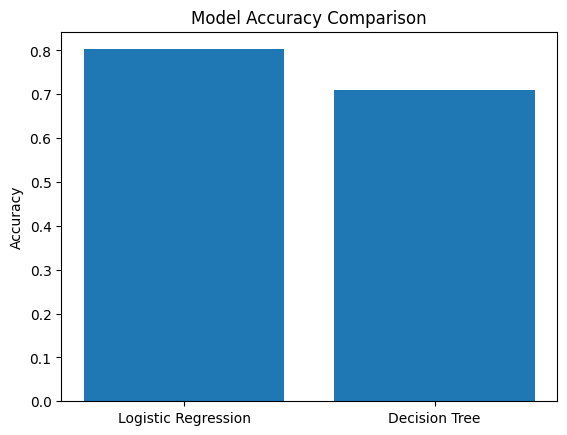

In [10]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Decision Tree']
accuracies = [lr_accuracy, dt_accuracy]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

## Rule-Based Churn Prediction

A simple rule-based approach is implemented using predefined conditions. This method does not learn from data but uses fixed logic to predict churn.

In [ ]:
def rule_based_churn(row):
    if row['Purchases'] < 5 and row['Membership'] == 0:
        return 1
    elif row['Income'] < 40000:
        return 1
    else:
        return 0

df['Rule_Prediction'] = df.apply(rule_based_churn, axis=1)

## Rule-Based Accuracy

The accuracy of the rule-based model is calculated. It is significantly lower because it cannot adapt to patterns in the data.

In [12]:
from sklearn.metrics import accuracy_score

rule_accuracy = accuracy_score(df['Churn'], df['Rule_Prediction'])
print("Rule-Based Accuracy:", rule_accuracy)

Rule-Based Accuracy: 0.2653698707936959


## Final Comparison of All Approaches

All approaches (Logistic Regression, Decision Tree, and Rule-Based) are compared based on accuracy.

In [13]:
print("\nFinal Comparison:")
print("Logistic Regression:", lr_accuracy)
print("Decision Tree:", dt_accuracy)
print("Rule-Based:", rule_accuracy)


Final Comparison:
Logistic Regression: 0.8026969481902059
Decision Tree: 0.7097232079489
Rule-Based: 0.2653698707936959


## Final Model Comparison Visualization

This bar chart compares the performance of all three approaches: Logistic Regression, Decision Tree, and Rule-Based model.

The accuracy values of each model are plotted to visually analyze their performance differences. Visualization makes it easier to interpret which model performs best.

From the chart, it is clear that Logistic Regression achieves the highest accuracy, followed by Decision Tree, while the Rule-Based model performs the worst. This shows that machine learning models are more effective than simple rule-based logic for predicting customer churn.

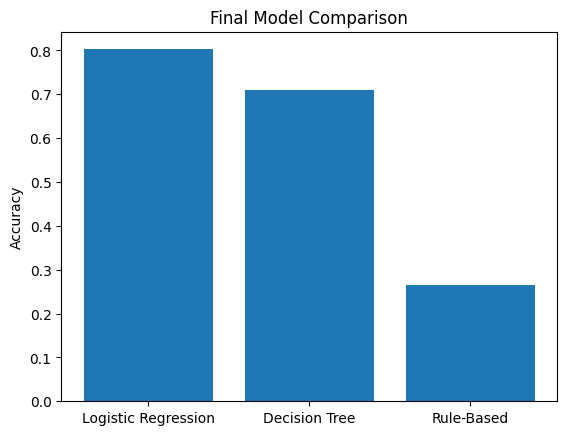

In [14]:
models = ['Logistic Regression', 'Decision Tree', 'Rule-Based']
accuracies = [lr_accuracy, dt_accuracy, rule_accuracy]

import matplotlib.pyplot as plt

plt.bar(models, accuracies)
plt.title("Final Model Comparison")
plt.ylabel("Accuracy")
plt.show()